# Lecture 5: Automatic Tests and Memory

Today's lecture will be actually split in two separate parts. In the first part of the lecture we will work on finishing the topic introduced in the last lecture about errors and automatic tests. We will work with distances and measures to understand both if some configuration are more or less afflicted by error (unluckly not distinguishable between cumulative and meta error) but also to find in a systematic way if there are some similarities between two probability distributions obtained for different values of the parameters.
In the second part of the lecture, we will talk about memory (actually only time memory) and we can create a "memory effect" based on the previous configurations on the evolution of the trajectory for a system. For this we will work on a model presented in [this paper](https://doi.org/10.1016/j.physd.2026.135143)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import random

## Exercise 1: Error tests

Let's continue where we have finished last time. In the previous lecture we have introduced the Kullback-Leiber distance as a measure between two probabilities distribution. Our idea was to compare for integrable cases the value of the theoretical distribution obtained from the Fokker-Plank equation with the distribution obtained from trajectories sampling. We have already discussed some issues that can raise from the KL distances hypothesis and how to managed them.

In [2]:
def kullback_leiber(P: np.array,Q: np.array)->float:
    '''
    This function will compute the Kullback-Leiber distance between
    the distributions P and Q. P should be the simulative distribution
    while Q the analytical one
    '''

    #First we have to check that the array have the same length
    if(len(P)!=len(Q)):
        raise RuntimeError("The length of the arrays of the two distributions must be the same")

    DKL = 0.0

    for i in range(len(P)):
        if(P[i]>0.0 and Q[i]>0.0):
            DKL += P[i]*np.log2(P[i]/Q[i])

    return DKL

In [3]:
class Harvest(object):

    #CONSTRUCTOR:
    def __init__(self,a: float,k: float,s: float)->None:
        #First let's check the inputs
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function is used to change the value of the params between a iteration and another
    def setParam(self,a: float,k: float,s: float)->None:
        '''
        This function recieve new values for the parameters (a,k,s)
        and, after some checks, use them as new params of the Harvest Process.
        '''
        if(a<0 or k<0 or s<0):
            raise RuntimeError("The system parameters must be non-negative.")

        self._a = a
        self._k = k
        self._s = s
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the PLS
        '''

        f = lambda x: self._a*x*(1-x)-self._k*x
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART
            eps = random.gauss(0,1)
            traj[i] += self._s*traj[i-1]*(1-traj[i-1])*np.sqrt(h)*eps #FIRST STOCHASTIC TERM
            traj[i] += 0.5*(self._s*traj[i-1]*(1-traj[i-1]))*(self._s*(1-2*traj[i-1]))*h*(eps*eps-1)

        return traj

Now we can finally analyse the error for different parameters configuration to spot where our method has more problem to simulate correctly the dynamical system. Before going on we need to consider first an important aspect. This way to measure the error is anything but perfect. Actually the idea of measuring the error has some issues due mainly to the degeneracy of multiple causes into a single value. When we measure the difference between the distribution and the results fo Fokker-Plank we are actually summing up, at least, three effects:

- Cumulative error
- Meta error
- Amplifications due to the discretization
- EXTRA: Other smaller (approximation,...)

We have already discussed the first two points while the last one is still unexplored. The third point is actually quite petty and it usaully appears when we have some divergent behaviour in a critical point. This is more intense when the FP is not integrable but can already appear for divergent yet integrable scenarios. When we do trajectories sampling we have also to perform a binning on our domain. Due to this splitting of the domain, the finite number of simulations and the stochastic nature of the phenomena we could have this kind of situations:

*Given a binning system we have as first two bins $[1000,500,...]$ while the value of the Fokker-Plank is $[1500,300]$. While for other parameters configuration this difference is more diluted on the domain here a difference in value but not in the final behaviour can raise enormous error.*

As you can notice this is independent by the measure we are adopting but is more a methodological thing. The only solution is to take account of this possibilities.

Now we can start to analyse the error for the different configurations. We have that the value of $k$ and $a$ are not actually dependant in their absolute value but the only important thing is their ratio $k/a$ so we can simply fix $a=1.0$ and change $k$. We have suppose that $0\leq k/a\leq 1$ so we will have the same domain for $k$ only. For $s$ we have seen that the meaningful value can change so we will consider the whole domain so $0\leq s< \sqrt{2}$. 

With these observations upon the domain of the parameters space we can define a 2D grid. We will consider 10 points for each axis and to avoid possible problems at the limit of our domain we will start not from 0 and we will not arrive to exactly the upper limit. This is needed because at the divergence point, even if the value is integrable we cannot have in the simulation an infinite high peak so the error will be infinity in this point. 

A similar problem happens when we have too small stochastic fluctuations in fact exists a certain value in which case we will have no more a finite peak but an infinite one (due to the convergent deterministic behaviour). If you do some tests you will find that it's around $0.10-0.15$ for low $k$s but it has some kind of dependance from $k$ that makes it smaller with k growing. This case is no so easily eliminable without doing internal checks in the integral and KL methods so we will simply exclude this cases from our analysis starting from an $s_{base}=0.15$ 

In [4]:
#CREATION OF THE GRID FOR THE PARAMETERS'SPACE

N = 10

delta_k = 1/N
delta_s = (np.sqrt(2)-0.15)/N

k_grid = np.zeros(N,dtype=float)
s_grid = np.zeros(N,dtype=float)

for i in range(N):
    k_grid[i] = (i+0.5)*delta_k
    s_grid[i] = (i+0.5)*delta_s+0.15

print(k_grid)
print(s_grid)

[0.05 0.15 0.25 0.35 0.45 0.55 0.65 0.75 0.85 0.95]
[0.21321068 0.33963203 0.46605339 0.59247475 0.7188961  0.84531746
 0.97173882 1.09816017 1.22458153 1.35100288]


We need also to define a function to compute for each set of parameters the normalization constant A.

In [5]:
def compute_norm_cost(a: float,k: float,s: float,N: int,omega_l:float,omega_t: float)->float:
    '''
    Given the three parameters, this function will compute the normalization
    constant of the analytical distribution using the trapezoidal rule in N steps
    '''

    #Introduce the formula of the analytical distribution
    P_s = lambda x: (1-x)**(-(2*(a+s**2-k))/s**2)*x**(-(2*(-a+s**2+k))/s**2)*np.exp(2*k/(s**2*(x-1)))

    #Define the grid and the step
    y = np.linspace(omega_l,omega_t,N+1)
    h = 1.0/N

    #Initialize integral
    I = 0.0

    #We need to stop at N-1 because the last point is equal to 1.0 and it's not defined for this value.
    for i in range(N-1):
        I += h*(P_s(y[i])+P_s(y[i+1]))/2

    return 1.0/I

Now we can produce the difference for every configuration

In [6]:
#PRODUCTION CODE

#SET SIMULATIONS CHARACTERISTICS
omega = [0.01,0.99] 
Nbins = 250 
Nsim = 2500
m = (omega[1]-omega[0])/Nbins

#SET DOMAIN AND CHARACTERISTICS FOR THE ANALYTIC SOLUTION
y = np.linspace(omega[0],omega[1],Nbins+1)
y = y[0:-1]
P_s = lambda x,a,k,s: (1-x)**(-(2*(a+s**2-k))/s**2)*x**(-(2*(-a+s**2+k))/s**2)*np.exp(2*k/(s**2*(x-1)))

#SET THE ERROR MATRIX
err = np.zeros((len(k_grid),len(s_grid)),dtype=float)

for k in range(len(k_grid)):
    for j in range(len(s_grid)):
        if(s_grid[j]**2<2*(1.0-k_grid[k])):
            system = Harvest(1.0,k_grid[k],s_grid[j])
            
            bins = np.zeros(Nbins,dtype=float)
            
            for _ in range(Nsim):
                p = system.computeTraj(100,0.1,random.uniform(omega[0],omega[1]))[-1]
                for i in range(Nbins):
                    if p < (m*(i+1)+omega[0]):
                        bins[i] += 1.0
                        break

            t_bins = bins/(Nsim*m)
            A = compute_norm_cost(1.0,k_grid[k],s_grid[j],1000,omega[0],omega[1])

            err[k,j]=kullback_leiber(t_bins,A*P_s(y,1.0,k_grid[k],s_grid[j]))

Let's plot it in a form of colormesh

C:\Users\loren\AppData\Local\Temp\ipykernel_20596\629271269.py:8: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(s_grid,k_grid,np.log(err),cmap='plasma')
C:\Users\loren\AppData\Local\Temp\ipykernel_20596\629271269.py:8: RuntimeWarning: invalid value encountered in log
  plt.pcolormesh(s_grid,k_grid,np.log(err),cmap='plasma')


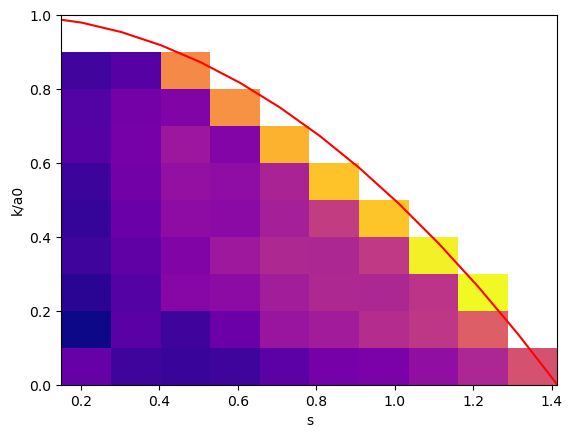

In [7]:
x=np.linspace(0,10,100)

plt.plot(x,(1-x**2/2),color='r')
plt.xlabel("s")
plt.ylabel("k/a0")
plt.xlim(min(s_grid-delta_s/2),max(s_grid+delta_s/2))
plt.ylim(min(k_grid-delta_k/2),max(k_grid+delta_k/2))
plt.pcolormesh(s_grid,k_grid,np.log(err),cmap='plasma')

The red line is a delimitation marker for the integrable region.
We can make some observations looking at this graphical representation:

1. Firstly we can think a bit about the errors we are finding. As we can notice we have a divergence for the entire first row. In fact for that values we have our attractor point located in $0.05$-something due to the $s$ (do you remember what happens when you grow with $s$ to the upper stable point in this condition?). Thus in this situation it is very difficult to separate the two critical points producing a de-facto divergence due to the fusion.
2. Anyway, for the other points we have obtained good results. If you like, you can also use library such as Seaborn to print the value of each cell upon it to have an improve readability. Looking at the colormesh we can see that the error grows with bigger fluctuations (it makes sense) and grows with greater $k$. In this way know where our simulation can move away from the solutions.
3. An indirect gain obtainable with this computation is, modifying the code a bit, that we can save in some variables all of these distributions and in such way produce, using an automated codes, all the plots. With all the plots obtained we can also create a mega-plot similar to the colormesh above but with the plot distribution in each cell. This mega-plot will allow us to see rapidly the differences moving along the parameters.

## Exercise 2: Parameters links

In this second part of the tutoring, I would like to talk about an interesting topic which is the parameter links. This topic can be divided in two macro aspects:

- The parameters's "weights" on the equations
- The links between the parameters

Talking about the first one, when we are working with a complex model there could be a lot of parameters to consider. To perform an analysis of the entire parameter space as done before is impossible and also the qualitative analysis can be quite a mess. The equations (we will see it below) are usually not easily writable in a single clean form but we have to use "converters". In this chaos, if we are able to eliminate some parameters by our analysis could be very helpful. We will try to see if there are some way to understand which parameters can be fixed during our analysis. About this I will not talk about in this section because it will be a very long topic which require some qualitative analysis coadjuvate by some simulations (If you like we can discuss it in the last lecture).

The second points also regards the number of the parameters. In fact, sometimes, we have that our system do not depend directly on the absolut value of a parameter but to the ratio or a relationship with another parameter. This fact can give us the opportunity to reduce the total number of parameters in our system and doing so we can reduce the number of computation or considerations needed to study the behaviour of the system. I would like to talk about this.

**PREMISES**: Finding the links between the parameters should be ideally done using qualitative analysis however, especially in very complex systems, it's almost impossible to do so (differential equations with 30+ terms). On the other hand, using for this little explanation a such complex system will require a lot of time also to explain merely the equations and the relationships between the variables. For this reason we will cheat a bit considering our well-known **Stochastic Harvest Process** where we know that there is a relationship between $k/a$.

### Step 1

So considering the harvest process, we have the following equation that describe our system:

$$
\frac{dx}{dt}=a(x(1-x))-kx-s(x(1-x))\xi(t)
$$

and let's imagine we are not able to do any kind of qualitative analysis. We want to try if there are some links between.

To hold our scenario in the easiest situation,let's cheat again another bit and let's fix, at least at first, s=0.0001 that will simulate the situation with almost no $s$. We know in fact that for growing $s$ the attractor point moves and we want to keep $s$ fixed in first instance. This is actually done when you want to find at first the deterministic properties. 

Now we can imagine that if there are some kind of relationship between $a$ and $k$ (e.g. $k^2/a=cost.$) we will have that some distributions for different combinations should coincide with a small error in comparison with the others. Obviously this is not an absolut method and the choice for the distance and other aspects can influence a lot our results but we can be improved initializing all the time the method using the same seeds for all the levels of RNG. For this small experiment we will simply look to the results using a lot of simulations but keeping our seed random.

Before starting, we will need this time a new distance because the Kullback-Leiber request of having $Q>0$ is too tight when we confront two binning distributions. For this case we will use the **total variation distance** in its equivalence with the $L^1$ norm

$$
\delta(P,Q)=\frac{1}{2}\sum_{k=1}^n |P(x_k)-Q(x_k)|
$$

instead of the KL distance; this has no problems with 0 values.

In [8]:
def total_var_dist(P:np.array,Q:np.array,h:float)->float:
    '''
    This function will compute the total variation distance 
    using the equivalence with the L^1 norm.
    '''

    if(len(P)!=len(Q)):
        raise RuntimeError("The length of the arrays of the two distributions must be the same")

    dist=0.0
    
    for i in range(len(P)):
        dist += np.abs(P[i]-Q[i])

    return dist/2

### Step 2

Now we can sample $a$ and $k$. We have not a precise idea where we want to look more than $a,k>0$ so let's take the domain $[0.001,1.0]$ for both of them. We start from this value because for lower have almost no sense and we have also impose non 0 condition for $a$ and $k$ also in the problem. We will only sample 9 points each to make it easier as possible (it's important because we will need to compute the cross distance between all the computations).

In [9]:
N= 9

a_grid = np.linspace(0.001,1.0,N)
k_grid = np.linspace(0.001,1.0,N)

print(a_grid)
print(k_grid)

[0.001    0.125875 0.25075  0.375625 0.5005   0.625375 0.75025  0.875125
 1.      ]
[0.001    0.125875 0.25075  0.375625 0.5005   0.625375 0.75025  0.875125
 1.      ]


And now we produce the distance for every couple

In [11]:
#PRODUCTION CODE

omega = [0,1] 
Nbins = 250 
Nsim = 1000
m = (omega[1]-omega[0])/Nbins

#Create the matrix to save all the distributions
distributions = np.zeros((N,N,Nbins),dtype=float)

for k in range(len(a_grid)):
    for j in range(len(k_grid)):
        #SAME OLD THINGS
        system = Harvest(a_grid[k],k_grid[j],0.0001) #We only change here to pass the parameters values!
        
        bins = np.zeros(Nbins,dtype=float)
        
        for _ in range(Nsim):
            p = system.computeTraj(100,0.1,random.uniform(omega[0],omega[1]))[-1]
            for i in range(Nbins):
                if p < (m*(i+1)+omega[0]):
                    bins[i] += 1.0
                    break

        t_bins = bins/(Nsim*m)

        distributions[k,j,:]=t_bins #And here we save the values into the array

### Step 3

Now we can compute all the cross distances and now we can see why we have keep the value of $N$ quite low. Also being the distance symmetric we can simply compute half of the matrix and also the diagonal is trivially null.

In [12]:
import math 
#I import math to use the floor function!

In [13]:
#Prepare the names for the axis' ticks
sets_names = []

for i in range(N):
    for j in range(N):
        sets_names.append(str(i)+"-"+str(j))

In [14]:
#Compute the matrix of the cross distances
dist = np.zeros((N**2,N**2),dtype=float)

for i in range(N**2):
    for j in range(N**2):
        if(j>=i+1):
            dist[i,j]=total_var_dist(distributions[math.floor(i/N),i%N,:],distributions[math.floor(j/N),j%N,:],m)

C:\Users\loren\AppData\Local\Temp\ipykernel_20596\4153022345.py:27: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(np.arange(N**2),np.arange(N**2),np.log(dist),cmap="plasma")


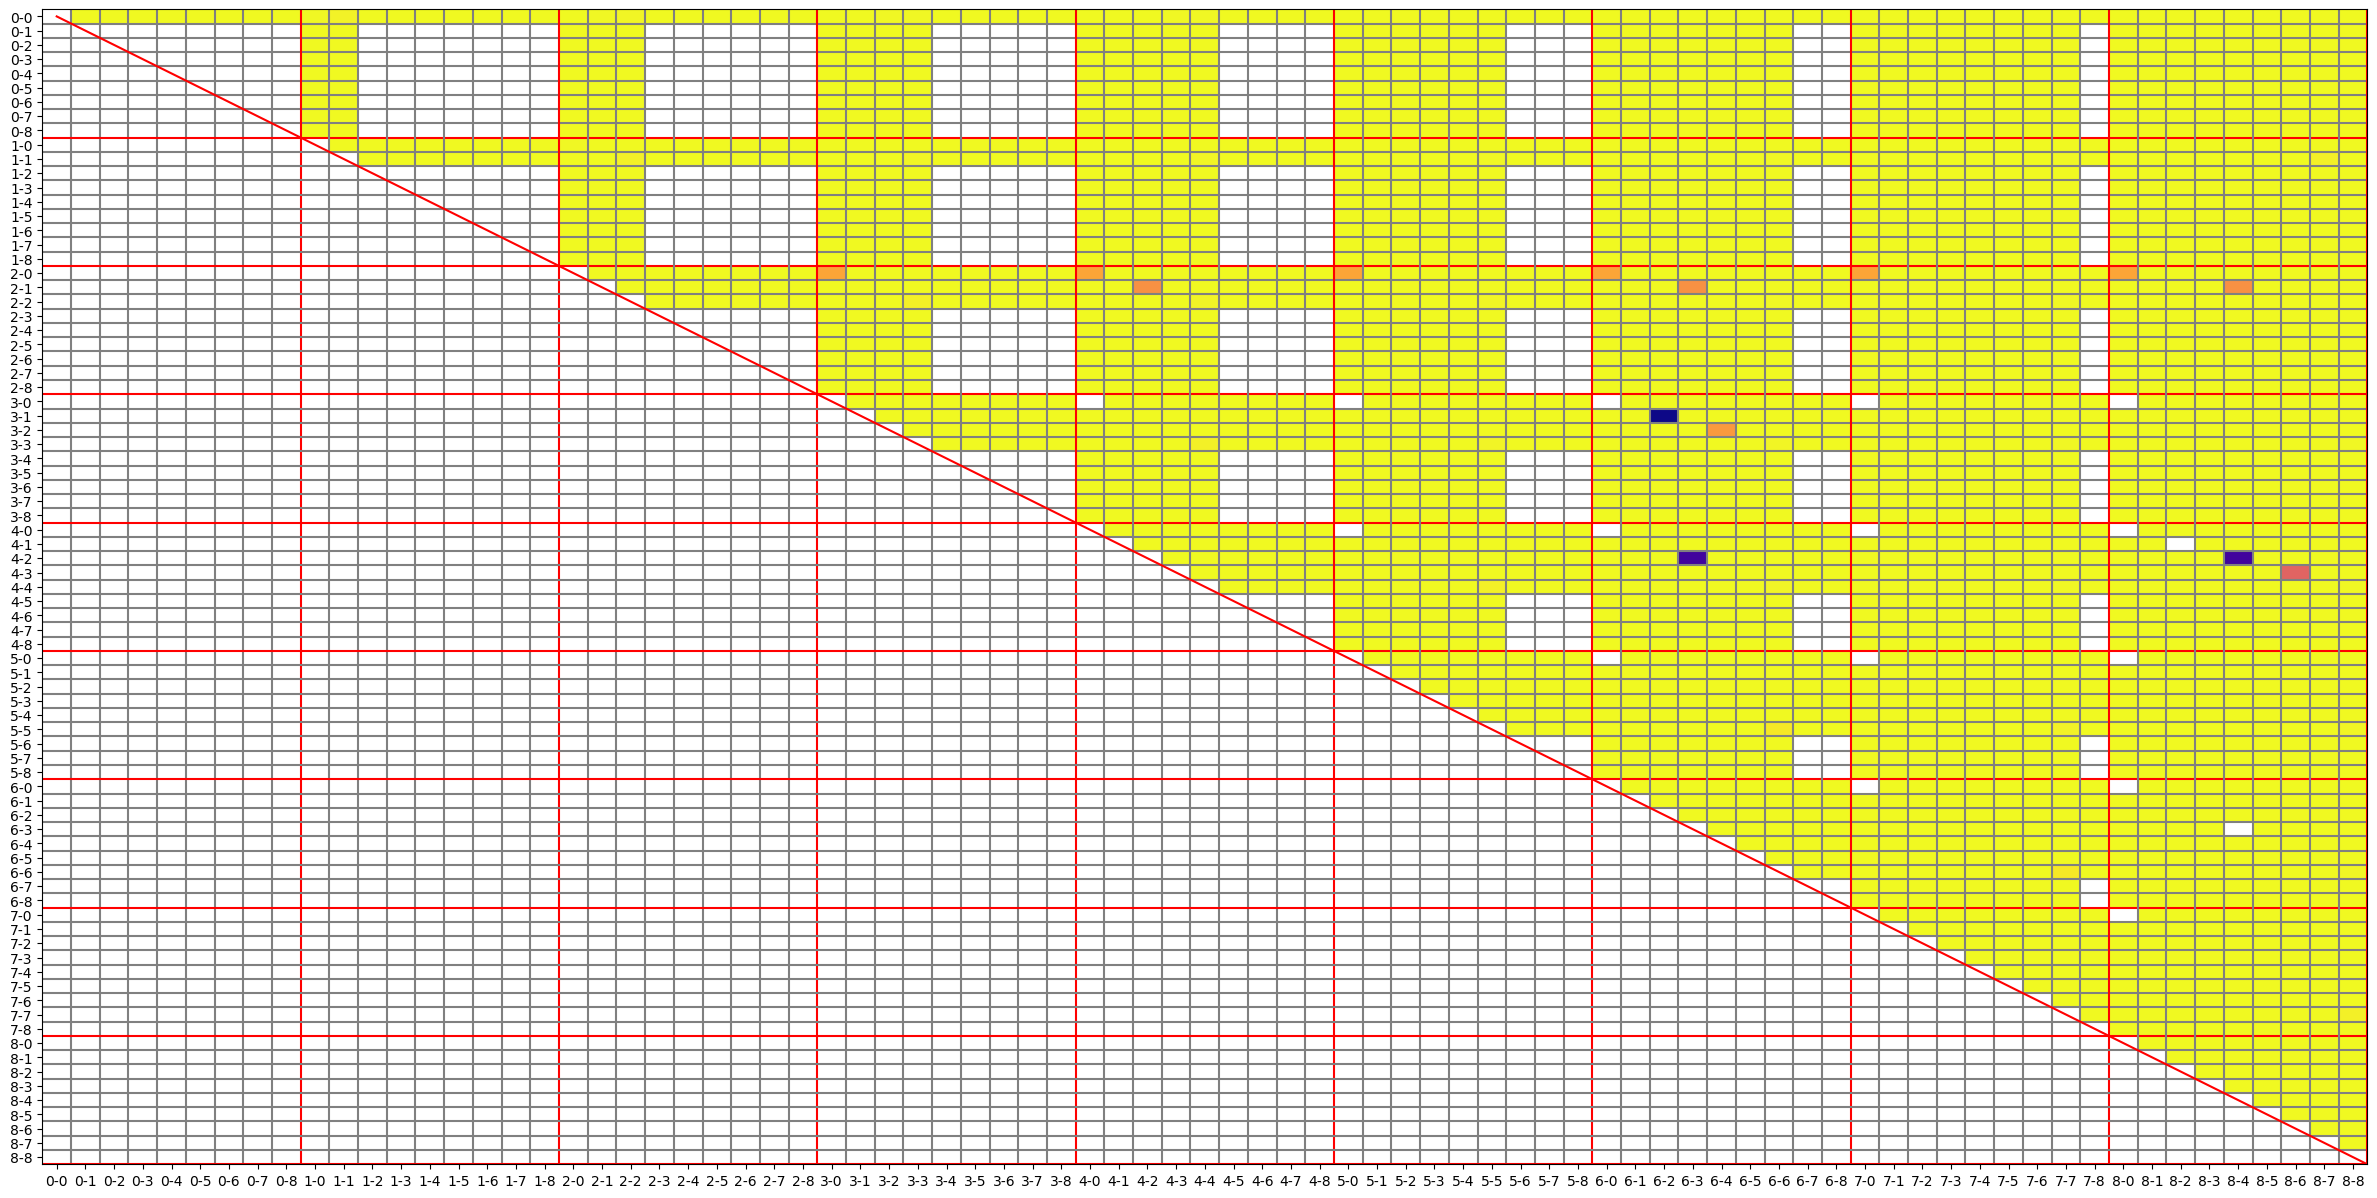

In [15]:
#YAH! IT'S PLOTTING TIME!


fig = plt.figure(figsize=(30, 15)) #Bigger figure
plt.gca().invert_yaxis() #Invert y axis to have the same form of the dist vector
plt.xticks(np.arange(N**2),sets_names) #Ticks label on x
plt.yticks(np.arange(N**2),sets_names) #Ticks label on y

#Horizontal and vertical grid
for i in range(N**2):
    if(i%N!=N-1):
        plt.axhline(y=i+0.5, color='grey', linestyle='-')
        plt.axvline(x=i+0.5, color='grey', linestyle='-')
    else:
        plt.axhline(y=i+0.5, color='r', linestyle='-')
        plt.axvline(x=i+0.5, color='r', linestyle='-')
        

#Diagonal line
x = np.linspace(0,N**2,100)
plt.plot(x,x,color='r')

plt.xlim(-0.5,N**2-0.5)
plt.ylim(N**2-0.5,-0.5)

#The actual colormesh plot
plt.pcolormesh(np.arange(N**2),np.arange(N**2),np.log(dist),cmap="plasma")

*This plot to your eyes: I will make end this man whole career...*

WOW! Jokes aside, There are a lot of things here. Let's try to analyze a bit what this colormesh is telling us:

- Firstly all the yellow cells have an enormous error so probably there are no links.
- Talking about the line of colored cells in 2-0: if we take a look to the junctions we can observe that all the couple are made with another *-0 distribution. So if $k=0$ we obtain the same plot. This is also visible for 3-0, 4-0, ... but this time the error is perfectly 0. For 1-0 there is no strong correlation so a further analysis is required. In this situation we have that $a=0.1258...$ so it's quite small. A possible problem could be the length of the simulations.
- Talking about the line of colored cells in 2-1: here if we look at junctions we can observe that 4-2, 6-3 and 8-4 have the same ratio which is 1/2. For the other two colored point below the same observation can be made.
- Talking about the orangish diagonal cells (sometimes is more visible than other): They are all for $k=a$ so again we have a same ratio convergence however for this $k/a$ the simulation is probably a bit cranky, as seen before, so the error is still higher.
- **NEWS**: we have white points. As you can observe there a lot of white points in our colormesh so it could be interesting to analyze why it happens: it's truly a link or there are some problems with the simulation/computation of the distances? To integrate this colormesh one could start to check the combinations simply plotting it to understand the problem and then looking to the other white cells trying to find some links. There is obviously something recurrent because we have a geometric scheme for this combinations. I leave it to you!

Obviously part of this analysis can be automatized using some methods to extract the lowest values etc... without losing an eye on this dazzeling but useful image

### Step 4

We can try now a little bit redoing all of this computation but with $s=0.25$ which is a bigger but not an huge value.

In [16]:
#PRODUCTION CODE

omega = [0,1] 
Nbins = 250 
Nsim = 1000
m = (omega[1]-omega[0])/Nbins

#Create the matrix to save all the distributions
distributions = np.zeros((N,N,Nbins),dtype=float)

for k in range(len(a_grid)):
    for j in range(len(k_grid)):
        #SAME OLD THINGS
        system = Harvest(a_grid[k],k_grid[j],0.25) #We only change here to pass the parameters values!
        
        bins = np.zeros(Nbins,dtype=float)
        
        for _ in range(Nsim):
            p = system.computeTraj(100,0.1,random.uniform(omega[0],omega[1]))[-1]
            for i in range(Nbins):
                if p < (m*(i+1)+omega[0]):
                    bins[i] += 1.0
                    break

        t_bins = bins/(Nsim*m)

        distributions[k,j,:]=t_bins #And here we save the values into the array

In [18]:
#Prepare the names for the axis' ticks
sets_names = []

for i in range(N):
    for j in range(N):
        sets_names.append(str(i)+"-"+str(j))

In [19]:
#Compute the matrix of the cross distances
dist = np.zeros((N**2,N**2),dtype=float)

for i in range(N**2):
    for j in range(N**2):
        if(j>=i+1):
            dist[i,j]=total_var_dist(distributions[math.floor(i/N),i%N,:],distributions[math.floor(j/N),j%N,:],m)

C:\Users\loren\AppData\Local\Temp\ipykernel_20596\4153022345.py:27: RuntimeWarning: divide by zero encountered in log
  plt.pcolormesh(np.arange(N**2),np.arange(N**2),np.log(dist),cmap="plasma")


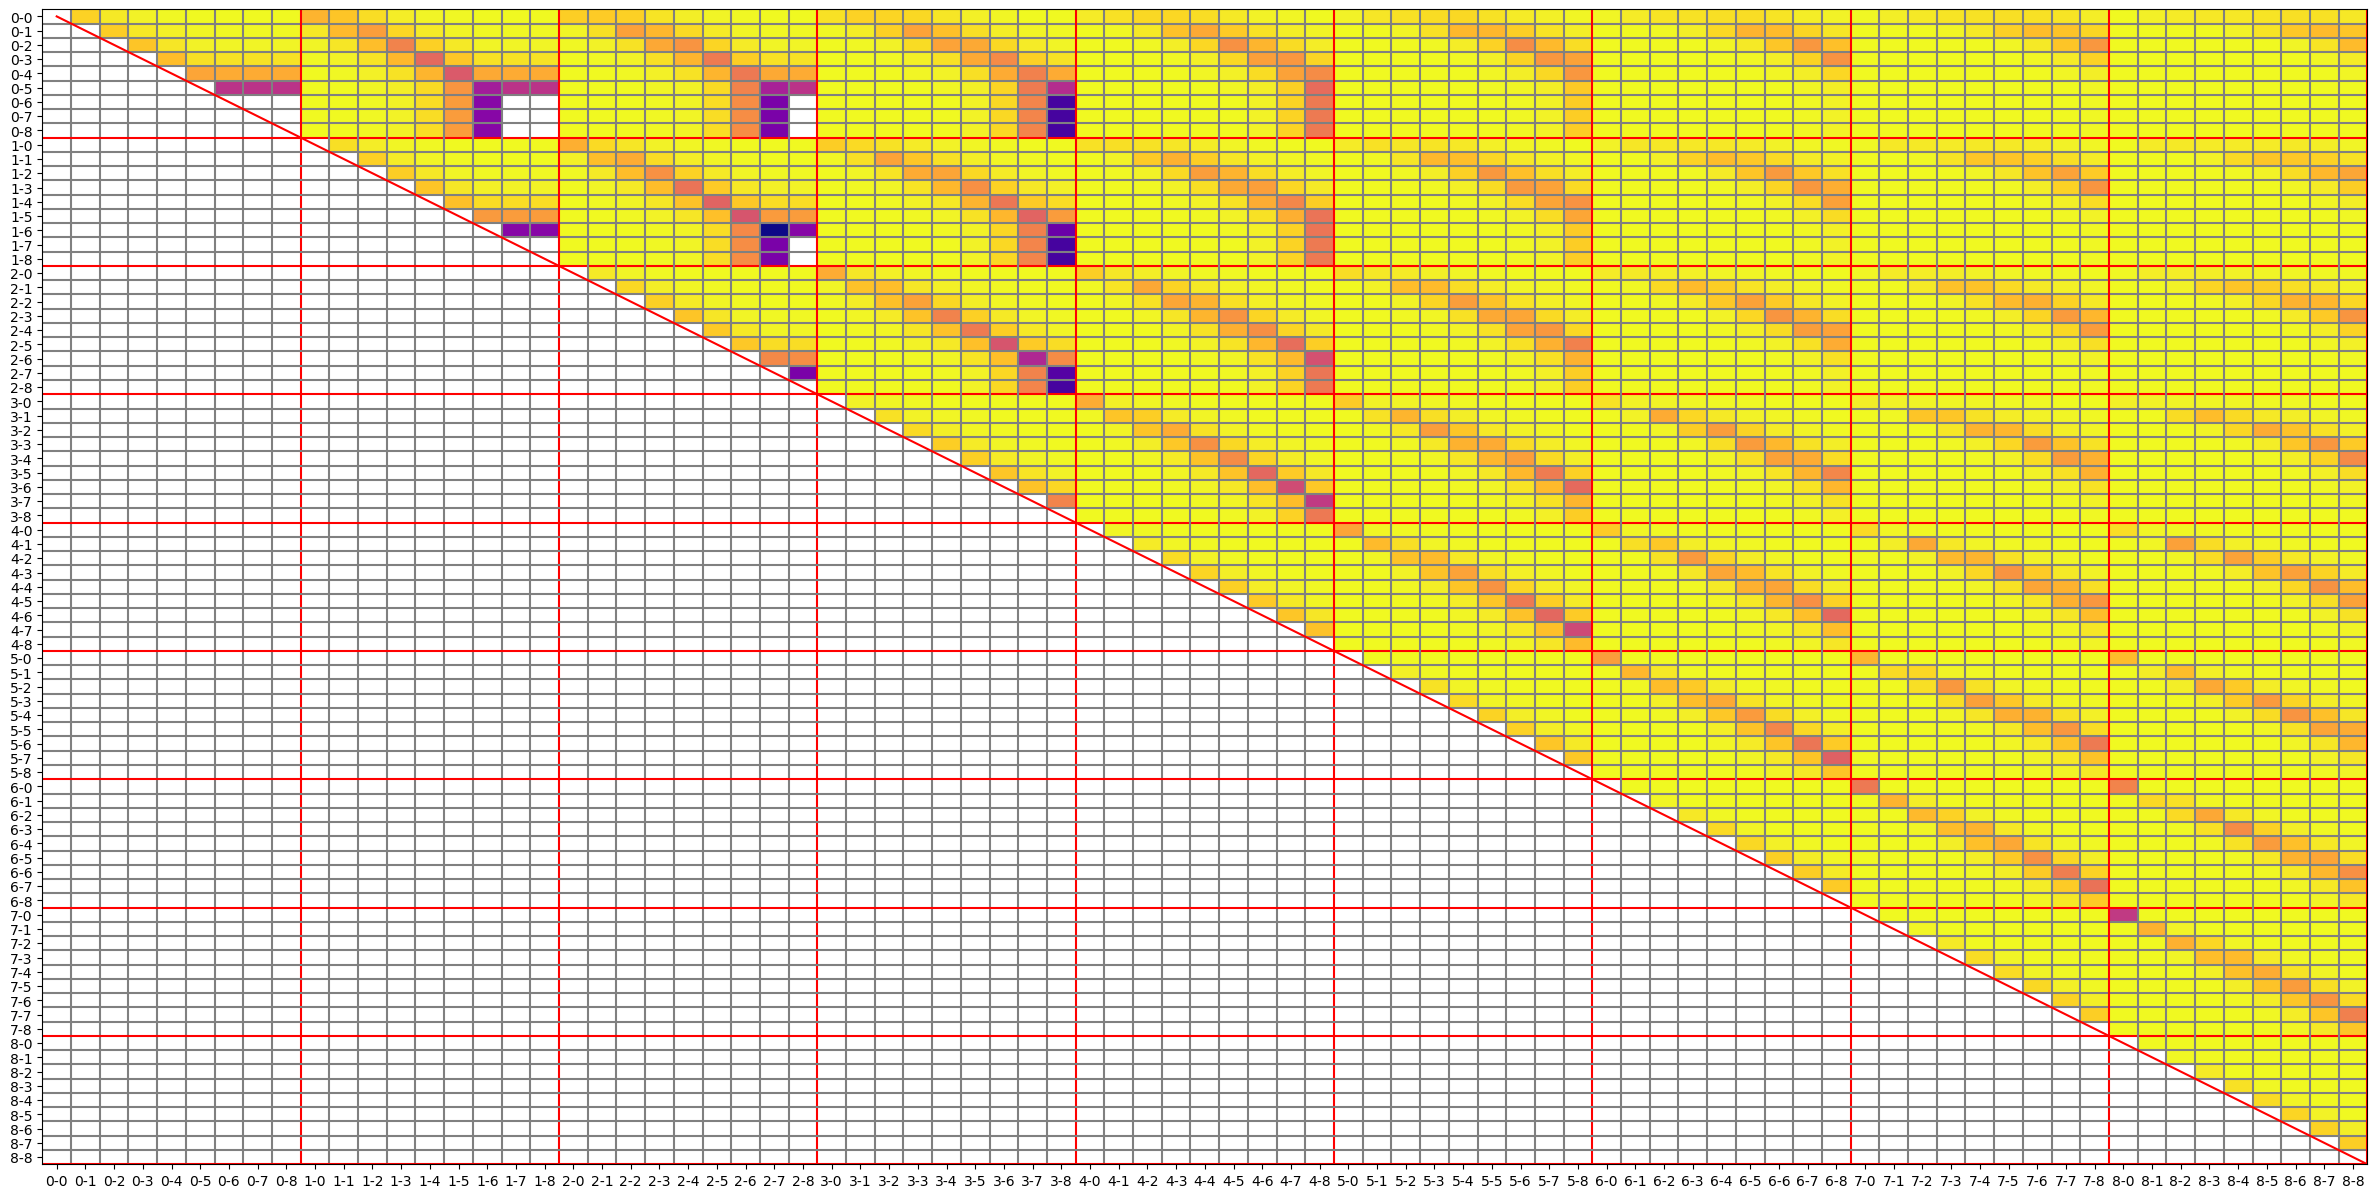

In [20]:
#YAH! IT'S PLOTTING TIME!


fig = plt.figure(figsize=(30, 15)) #Bigger figure
plt.gca().invert_yaxis() #Invert y axis to have the same form of the dist vector
plt.xticks(np.arange(N**2),sets_names) #Ticks label on x
plt.yticks(np.arange(N**2),sets_names) #Ticks label on y

#Horizontal and vertical grid
for i in range(N**2):
    if(i%N!=N-1):
        plt.axhline(y=i+0.5, color='grey', linestyle='-')
        plt.axvline(x=i+0.5, color='grey', linestyle='-')
    else:
        plt.axhline(y=i+0.5, color='r', linestyle='-')
        plt.axvline(x=i+0.5, color='r', linestyle='-')
        

#Diagonal line
x = np.linspace(0,N**2,100)
plt.plot(x,x,color='r')

plt.xlim(-0.5,N**2-0.5)
plt.ylim(N**2-0.5,-0.5)

#The actual colormesh plot
plt.pcolormesh(np.arange(N**2),np.arange(N**2),np.log(dist),cmap="plasma")

Well some of the previous behaviour are still present but we can see that the stochastic fluctuations depolarize some situations and transform some distributions making them similar!

## Exercise 3: Time Memory

In this last part of the lecture, we will talk about memory. The idea is fairly simple: usually the forcing term (the right hand side) of a differential equation is represented by a field. The *field* is actually a real field in the physical meaning if we think about. In each point I have a vector that moves my trajectory towards a certain direction. If we think about the process, also in a purely deterministic framework, is "markovian"-like, using improperly the term. The sense is that the process depends usually only by the last considered point. Therefore, given two trajectories that arrives in the same point of the state space they will share after that point the same track. If we think about our simulative method is based exactly on this assumption.

We would like to able to insert an influence based on the trajectory in our systems and we would like to do that without losing the framework base on the differential equatins either changing our simulative method. This requests are the base idea of the **Memory Kernels** approach which allow us adding some dimensions to our state space to keep track of the previous step of our trajectory and to use them even with some customs and complex weights. 

To do this, we will work with a model taken from the above-quoted paper:

$$
x'=x(1-x)(x_e-M_v); \qquad M_v(t)=\int_0^{+\infty}W_v(\tau)x(t-\tau)d\tau
$$

As we can see this model is an evolutionary imitation game (it looks like a logistic but it is not). $M_v$ is the so-called memory kernel and it is used to incarnate the influence of the previous time instants on the field. This depends strongly on the shape of the weighting function $W_v(\tau)$. If $W_v(\tau)=\delta(t-\tau)$ it falls back to the classical last point dependency. There are tons of possible choice, we will use one of them.

One of the most common choices for both spatial and time kernels is the **Exponentially Fading Kernel** or **EFK**. With this kernel we have that $W_v(s)=a\exp(-as)$ thus the memory decrease exponentially in time backward. Therefore the nearest instants will be more impactful than the more distant one. Now, computing at every time step that integral is quite cumbersome but luckly it can be shown that considering the system with such definition of the memory kernel it is equivalent with EFK to have:

$$
\begin{cases}
x'=x(1-x)(x_e-M_v)\\
M_v'=a(x-M_v)
\end{cases}
$$

Thus we have a system of two differential equations. As said, we were able to create a memory effect adding a dimension to our parameter space. We can also think of $a$ as $a=1/\tau$ where $\tau$ is the chracteristic time of the memory effect. 

### The deterministic case case

We can study if this deterministic system has some differences in the trajectories and behaviours for with and without memory. Let's consider $x_e=0.5$ (the critical central attractor point) and $a=18$ in the EFK case. Let's start!

We can recycle the old class structure but now we need to manage the fact that we need to handle two variables: $x$ and $M_v$! But now we have only the system without memory thus we can manage it in the old way

In [27]:
class EvoGameNM(object):

    #CONSTRUCTOR:
    def __init__(self,x_e: float)->None:
        #First let's check the inputs
        if(x_e<0 or x_e>1):
            raise RuntimeError("x_e must be between 0 and 1.")

        self._x_e = x_e
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: float,h: float)->float: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the Evolutionary Imitation Game without Memory.
        '''

        f = lambda x: x*(1-x)*(self._x_e-x)
        
        k_1 = f(y_n)
        k_2 = f(y_n+h*k_1/2)
        k_3 = f(y_n+h*k_2/2)
        k_4 = f(y_n+h*k_3)

        return h*(k_1+2*k_2+2*k_3+k_4)/6
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: float)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")
        if(x0<0):
            raise RuntimeError("The initial size of the population must be non negative.")

        #2. Now we can set the output and start simulate
        traj = np.zeros(n_step+1,dtype=float)
        traj[0] = x0

        for i in range(1,n_step+1):
            traj[i] = traj[i-1]+self.__RK4(i*h,traj[i-1],h) #DETERMINISTIC PART

        return traj

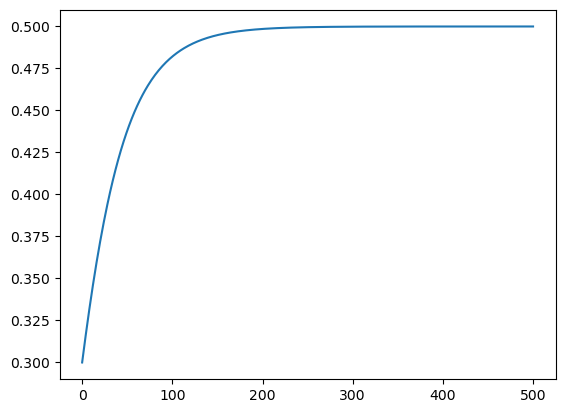

In [28]:
system = EvoGameNM(0.5)
t = system.computeTraj(500,0.1,0.3)
plt.plot(t)

Ok, it is a typical convergent behaviour towards the single attractor in $x_e=0.5$. Let's implement the case with EFK kernel and test it with $\tau=18$ !

In [35]:
class EvoGameEFK(object):

    #CONSTRUCTOR:
    def __init__(self,x_e: float,tau: float)->None:
        #First let's check the inputs
        if(x_e<0 or x_e>1):
            raise RuntimeError("x_e must be between 0 and 1.")
        if(tau<=0):
            raise RuntimeError("tau must be positive.")

        self._x_e = x_e
        self._tau = tau
        return

    #This function will be used to evolve the deterministic part of the field
    #using Runge-Kutta4
    def __RK4(self,t_n: float,y_n: np.array,h: float)->np.array: 
        '''
        Given a point in the trajectory, the time instant and the step lenght,
        this method will compute the variation for y using the RK4 for the 
        deterministic part of the Evolutionary Imitation Game with EFK.
        '''

        f_1 = lambda x,M_v: x*(1-x)*(self._x_e-M_v)
        f_2 = lambda x,M_v: (x-M_v)/self._tau
        
        k_1x = f_1(y_n[0],y_n[1])
        k_1y = f_2(y_n[0],y_n[1])
        
        k_2x = f_1(y_n[0]+h*k_1x/2,y_n[1]+h*k_1y/2)
        k_2y = f_2(y_n[0]+h*k_1x/2,y_n[1]+h*k_1y/2)
        
        k_3x = f_1(y_n[0]+h*k_2x/2,y_n[0]+h*k_2y/2)
        k_3y = f_2(y_n[0]+h*k_2x/2,y_n[0]+h*k_2y/2)
        
        k_4x = f_1(y_n[0]+h*k_3x,y_n[1]+h*k_3y)
        k_4y = f_2(y_n[0]+h*k_3x,y_n[1]+h*k_3y)

        output = np.zeros(2,dtype=float)
        output[0] = h*(k_1x+2*k_2x+2*k_3x+k_4x)/6
        output[1] = h*(k_1y+2*k_2y+2*k_3y+k_4y)/6

        return output
        
    #This function will produce a realization/trajectory for the system
    #using the Milstein discretization.
    def computeTraj(self,n_step: int,h: float,x0: np.array)->np.array:
        '''
        Given the number of step, the step length and the initial condition,
        this function will produce a trajectory using the Milstein method.
        '''

        #1. Perform some check of the arguments:
        if(n_step<0):
            raise RuntimeError("The number of step must be non-negative.")
        if(h<=0):
            raise RuntimeError("Step size must be positive.")

        #2. Now we can set the output and start simulate
        traj = np.zeros((n_step+1,2),dtype=float)
        traj[0,:] = x0

        for i in range(1,n_step+1):
            traj[i,:] = traj[i-1,:]+self.__RK4(i*h,traj[i-1,:],h) #DETERMINISTIC PART

        return traj

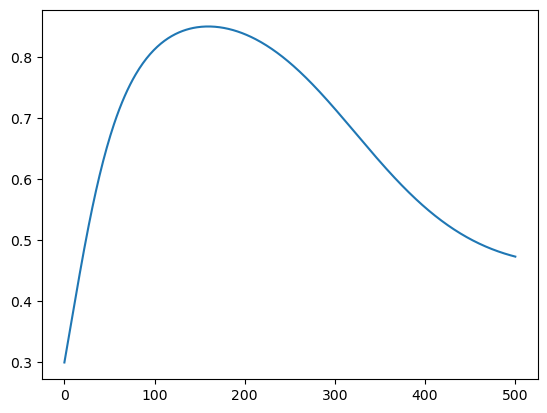

In [38]:
x0 = np.array([0.3,0.0])
system = EvoGameEFK(0.5,18)
t = system.computeTraj(500,0.1,x0)
plt.plot(t[:,0])

As we can notice we can already spot some differences in the transient behaviour. In fact, while in the case without memory the trajectory converged immediately to the critical point $x_e$ here it was able to produce a critical oscillation and then converge. Raising the $\tau$ even more it is possible to create damped oscillations. Obviously for small $\tau$ the two transient behaviour will converge. Nonetheless, it is also interesting to notice that at the steady state both the cases are similar with the solution that converges to the central critical point.